**Note: Run servers on local instead of Colab**

Here are some comments for a tutorial on Model serialization with Pickle/Joblib:

1. **Introduction to Model Serialization**:
   - Model serialization is the process of converting a machine learning model into a format that can be easily saved and loaded. This is crucial for deploying models in production environments or sharing them with others
.

2. **Why Use Pickle or Joblib?**:
   - Pickle and Joblib are two popular libraries in Python for serializing machine learning models. Pickle is a built-in Python module that can serialize and deserialize any Python object, including custom classes and objects
.
   - Joblib is more efficient than Pickle when working with large numpy arrays, making it a better choice for serializing large machine learning models
.

3. **Security Considerations**:
   - Both Pickle and Joblib use the pickle protocol under the hood, which can execute arbitrary code during unpickling. Therefore, it is important to only load models from trusted sources to avoid security risks
.

4. **Saving a Model with Pickle**:
   - To save a model using Pickle, you can use the `pickle.dump` function. This function serializes the model and writes it to a file. For example:
     ```python
     import pickle
     with open('model.pkl', 'wb') as file:
         pickle.dump(model, file)
     ```
   - This code opens a file in write-binary mode and uses Pickle to serialize the model into this file
.

5. **Loading a Model with Pickle**:
   - To load a model using Pickle, you can use the `pickle.load` function. This function reads the serialized model from a file and deserializes it. For example:
     ```python
     with open('model.pkl', 'rb') as file:
         model = pickle.load(file)
     ```
   - This code opens the file in read-binary mode and uses Pickle to deserialize the model from this file
.

6. **Saving a Model with Joblib**:
   - To save a model using Joblib, you can use the `joblib.dump` function. This function serializes the model and writes it to a file. For example:
     ```python
     from joblib import dump, load
     dump(model, 'model.joblib')
     ```
   - This code uses Joblib to serialize the model into a file named 'model.joblib'
.

7. **Loading a Model with Joblib**:
   - To load a model using Joblib, you can use the `joblib.load` function. This function reads the serialized model from a file and deserializes it. For example:
     ```python
     model = load('model.joblib')
     ```
   - This code uses Joblib to deserialize the model from the file named 'model.joblib'
.

8. **Performance Comparison**:
   - Joblib is generally faster than Pickle when dealing with large numpy arrays due to its optimizations for such data structures. However, Pickle may be faster for smaller models or models that do not contain large numpy arrays
.

9. **Use Cases**:
   - Use Pickle when you need to serialize small models or models that do not contain large numpy arrays. Use Joblib when you need to serialize large models or models that contain large numpy arrays
.

10. **Conclusion**:
    - Both Pickle and Joblib are powerful tools for model serialization. The choice between them depends on the size of your model and the data structures it contains. Always ensure that you load models from trusted sources to avoid security risks
.

In [18]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from scipy.stats import randint, uniform
import time
from sklearn.pipeline import Pipeline

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])
pipeline.fit(X_train, y_train)


,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [3]:
import pickle
version = '1.0.0'
filename_pkl = f'model_v{version}.pkl'

with open(filename_pkl, 'wb') as f:
    pickle.dump(pipeline, f, protocol=5)

print(f"Saved {filename_pkl}")


Saved model_v1.0.0.pkl


In [4]:
import joblib
filename_joblib = f'model_v{version}.joblib'
joblib.dump(pipeline, filename_joblib)


['model_v1.0.0.joblib']

In [5]:
with open(filename_pkl, 'rb') as f:
    model_pickle = pickle.load(f)
preds_pickle = model_pickle.predict(X_test)


In [6]:
with open(filename_pkl, 'rb') as f:
    model_pickle = pickle.load(f)
preds_pickle = model_pickle.predict(X_test)


In [7]:
model_joblib = joblib.load(filename_joblib)
preds_joblib = model_joblib.predict(X_test)


In [8]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, preds_pickle))
print(accuracy_score(y_test, preds_joblib))


0.9649122807017544
0.9649122807017544


In [9]:
import os
versions = ['1.0.0', '1.1.0', '2.0.0']
for v in versions:
    fname = f'model_v{v}.joblib'
    joblib.dump(pipeline, fname)
os.listdir('.')


['model_v1.0.0.joblib',
 'model_v1.0.0.pkl',
 'model_v1.1.0.joblib',
 'model_v2.0.0.joblib',
 'svm_default_learning_curve.png',
 'svm_optimized_learning_curve.png',
 'Week 4 - Day 3 Part2.ipynb',
 'Week 4 Day 3 Part1.ipynb']

In [10]:
import json
metadata = {
    'model_name': 'RandomForestPipeline',
    'versions': versions,
    'date_saved': {v: f'model_v{v}.joblib' for v in versions}
}
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f)


In [11]:
with open('model_metadata.json', 'r') as f:
    meta = json.load(f)
print(meta)


{'model_name': 'RandomForestPipeline', 'versions': ['1.0.0', '1.1.0', '2.0.0'], 'date_saved': {'1.0.0': 'model_v1.0.0.joblib', '1.1.0': 'model_v1.1.0.joblib', '2.0.0': 'model_v2.0.0.joblib'}}


Excercise

## Exercise Solution: Versioning, Validation, Benchmarking, and Serving


In [12]:
# ==============================================================================
# 1. TRAIN AND SAVE THREE VERSIONED MODELS
# ==============================================================================
from datetime import datetime, timezone
from pathlib import Path
import pickle
import joblib

version_seeds = {
    "1.0.0": 42,
    "1.1.0": 123,
    "2.0.0": 2024
}

version_records = []

for version, seed in version_seeds.items():
    version_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=100,
            random_state=seed
        ))
    ])

    version_pipeline.fit(X_train, y_train)

    pkl_name = f"model_v{version}.pkl"
    joblib_name = f"model_v{version}.joblib"

    # Pickle protocol 5
    with open(pkl_name, "wb") as f:
        pickle.dump(version_pipeline, f, protocol=5)

    # Joblib serialization
    joblib.dump(version_pipeline, joblib_name)

    version_records.append({
        "version": version,
        "random_state": seed,
        "pickle_file": pkl_name,
        "joblib_file": joblib_name,
        "saved_at": datetime.now(timezone.utc).isoformat()
    })

print("Saved model versions:")
for record in version_records:
    print(record)


Saved model versions:
{'version': '1.0.0', 'random_state': 42, 'pickle_file': 'model_v1.0.0.pkl', 'joblib_file': 'model_v1.0.0.joblib', 'saved_at': '2026-07-23T05:59:10.681700+00:00'}
{'version': '1.1.0', 'random_state': 123, 'pickle_file': 'model_v1.1.0.pkl', 'joblib_file': 'model_v1.1.0.joblib', 'saved_at': '2026-07-23T05:59:12.416700+00:00'}
{'version': '2.0.0', 'random_state': 2024, 'pickle_file': 'model_v2.0.0.pkl', 'joblib_file': 'model_v2.0.0.joblib', 'saved_at': '2026-07-23T05:59:14.531704+00:00'}


In [13]:
# ==============================================================================
# 2. CREATE MODEL METADATA CATALOG
# ==============================================================================
metadata = {
    "model_name": "RandomForestPipeline",
    "dataset": "Breast Cancer Wisconsin Diagnostic",
    "versions": version_records,
    "latest_version": "2.0.0"
}

with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print(json.dumps(metadata, indent=4))


{
    "model_name": "RandomForestPipeline",
    "dataset": "Breast Cancer Wisconsin Diagnostic",
    "versions": [
        {
            "version": "1.0.0",
            "random_state": 42,
            "pickle_file": "model_v1.0.0.pkl",
            "joblib_file": "model_v1.0.0.joblib",
            "saved_at": "2026-07-23T05:59:10.681700+00:00"
        },
        {
            "version": "1.1.0",
            "random_state": 123,
            "pickle_file": "model_v1.1.0.pkl",
            "joblib_file": "model_v1.1.0.joblib",
            "saved_at": "2026-07-23T05:59:12.416700+00:00"
        },
        {
            "version": "2.0.0",
            "random_state": 2024,
            "pickle_file": "model_v2.0.0.pkl",
            "joblib_file": "model_v2.0.0.joblib",
            "saved_at": "2026-07-23T05:59:14.531704+00:00"
        }
    ],
    "latest_version": "2.0.0"
}


In [15]:
# ==============================================================================
# 3. LOAD EVERY PICKLE AND JOBLIB MODEL AND MEASURE ACCURACY
# ==============================================================================
import time
from sklearn.metrics import accuracy_score
import pandas as pd

validation_results = []

for record in version_records:
    version = record["version"]

    # Pickle load + prediction
    start = time.perf_counter()
    with open(record["pickle_file"], "rb") as f:
        pkl_model = pickle.load(f)
    pickle_load_time = time.perf_counter() - start

    pickle_preds = pkl_model.predict(X_test)
    pickle_accuracy = accuracy_score(y_test, pickle_preds)

    # Joblib load + prediction
    start = time.perf_counter()
    joblib_model = joblib.load(record["joblib_file"])
    joblib_load_time = time.perf_counter() - start

    joblib_preds = joblib_model.predict(X_test)
    joblib_accuracy = accuracy_score(y_test, joblib_preds)

    validation_results.extend([
        {
            "Version": version,
            "Format": "Pickle",
            "Accuracy": pickle_accuracy,
            "Load Time (s)": pickle_load_time,
            "File Size (bytes)": os.path.getsize(record["pickle_file"])
        },
        {
            "Version": version,
            "Format": "Joblib",
            "Accuracy": joblib_accuracy,
            "Load Time (s)": joblib_load_time,
            "File Size (bytes)": os.path.getsize(record["joblib_file"])
        }
    ])

validation_df = pd.DataFrame(validation_results)
display(validation_df)


,Version,Format,Accuracy,Load Time (s),File Size (bytes)
0,1.0.0,Pickle,0.964912,0.014196,315651
1,1.0.0,Joblib,0.964912,0.626866,326434
2,1.1.0,Pickle,0.964912,0.028132,320771
3,1.1.0,Joblib,0.964912,0.894149,331554
4,2.0.0,Pickle,0.964912,0.007984,331821
5,2.0.0,Joblib,0.964912,0.233688,342594


,Format,Accuracy,Load Time (s),File Size (bytes),File Size (KB)
0,Joblib,0.964912,0.584901,333527.333333,325.710286
1,Pickle,0.964912,0.016771,322747.666667,315.183268


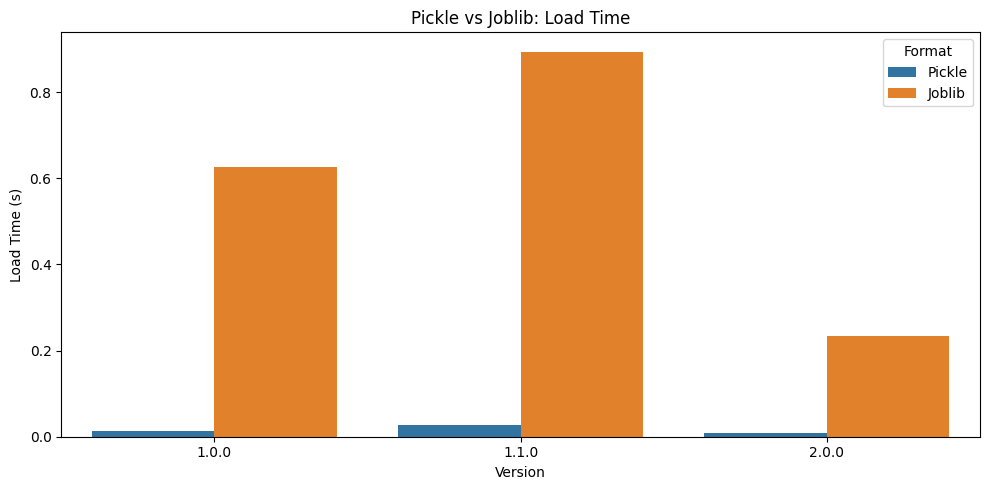

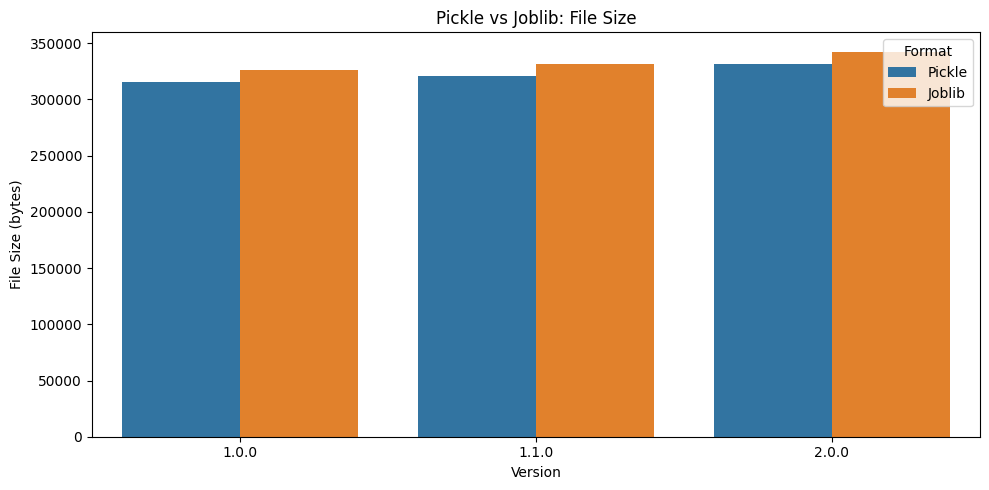

In [19]:
# ==============================================================================
# 4. COMPARE PICKLE VS JOBLIB
# ==============================================================================

format_summary = (
    validation_df
    .groupby("Format")
    .agg({
        "Accuracy": "mean",
        "Load Time (s)": "mean",
        "File Size (bytes)": "mean"
    })
    .reset_index()
)

format_summary["File Size (KB)"] = (
    format_summary["File Size (bytes)"] / 1024
)

display(format_summary)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=validation_df,
    x="Version",
    y="Load Time (s)",
    hue="Format"
)
plt.title("Pickle vs Joblib: Load Time")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=validation_df,
    x="Version",
    y="File Size (bytes)",
    hue="Format"
)
plt.title("Pickle vs Joblib: File Size")
plt.tight_layout()
plt.show()


### Brief Report: Pickle vs Joblib

Both Pickle and Joblib can serialize and restore the complete scikit-learn pipeline, including the `StandardScaler` and `RandomForestClassifier`. The accuracy should remain identical or effectively identical after loading because the same fitted model is being restored. The exact file sizes and loading times depend on the Python and library versions and the machine used to execute the notebook. Pickle is a general-purpose Python serialization mechanism, while Joblib is commonly convenient for scikit-learn models and can be efficient for models containing large numerical arrays. The benchmark table above provides the actual comparison for this environment rather than relying on theoretical expectations.


In [20]:
# ==============================================================================
# 5. LATEST MODEL LOADER
# ==============================================================================
with open("model_metadata.json", "r") as f:
    metadata = json.load(f)

latest_version = metadata["latest_version"]

latest_record = next(
    record for record in metadata["versions"]
    if record["version"] == latest_version
)

latest_model = joblib.load(latest_record["joblib_file"])

print(f"Loaded latest model: version {latest_version}")


Loaded latest model: version 2.0.0


### Overview  
This exercise guides you through training a scikit-learn pipeline, saving it with both Pickle and Joblib, managing model versions and metadata, and exposing the model via a simple Flask API  ([9. Model persistence — scikit-learn 1.6.1 documentation](https://scikit-learn.org/stable/model_persistence.html?utm_source=chatgpt.com)).  

### Tasks  
1. **Data Preparation:** Load the Breast Cancer Wisconsin dataset (`sklearn.datasets.load_breast_cancer`), split into train/test (80/20), and standardize features  ([Save and Load Machine Learning Models in Python with scikit-learn](https://machinelearningmastery.com/save-load-machine-learning-models-python-scikit-learn/?utm_source=chatgpt.com)).  
2. **Pipeline Construction:** Build an `sklearn.pipeline.Pipeline` with `StandardScaler` and `RandomForestClassifier(n_estimators=100, random_state=42)` and fit it on the training data  ([How to properly pickle sklearn pipeline when using custom ...](https://stackoverflow.com/questions/57888291/how-to-properly-pickle-sklearn-pipeline-when-using-custom-transformer?utm_source=chatgpt.com)).  
3. **Serialization:**  
   - Save the fitted pipeline using Pickle protocol 5 to `model_v1.pkl`.  
   - Save the same pipeline using Joblib to `model_v1.joblib`  ([Save Machine Learning Model Using Pickle and Joblib](https://www.analyticsvidhya.com/blog/2021/08/quick-hacks-to-save-machine-learning-model-using-pickle-and-joblib/?utm_source=chatgpt.com)).  
4. **Version Control:** Simulate versioning by retraining the pipeline with a different random seed, then saving as `model_v2.pkl`/`.joblib`; repeat for a third version. Create a `model_metadata.json` cataloging versions, file names, and timestamps  ([Machine Learning Model Serialization - Christopher Flynn](https://flynn.gg/blog/machine-learning-model-serialization/?utm_source=chatgpt.com)).  
5. **Deserialization & Validation:**  
   - Load each Pickle and Joblib file, run `.predict()` on the test set, and report accuracy.  
   - Measure and compare file sizes and load times between Pickle and Joblib  ([Pickle is over 10 times faster than joblib for save and load scikit ...](https://www.reddit.com/r/Python/comments/ypj13g/pickle_is_over_10_times_faster_than_joblib_for/?utm_source=chatgpt.com)).  
6. **Model Serving (Bonus):**  
   - Implement a minimal Flask app with two endpoints:  
     - `GET /models` returns available version metadata.  
     - `POST /predict` accepts JSON feature vectors and returns predicted classes using the latest model.  
   - Demonstrate sending requests via `requests` in Colab  ([Model Serialization using pickle and joblib - Kaggle](https://www.kaggle.com/code/tasnimniger/model-serialization-using-pickle-and-joblib?utm_source=chatgpt.com)).  

### Deliverables  
- A Colab notebook containing all code cells above.  
- The saved model files (`.pkl`, `.joblib`) and `model_metadata.json`.  
- A brief report (markdown cell) comparing Pickle vs Joblib in speed and size.  
- (Optional) The Flask app code cell demonstrating model serving.